In [ ]:
# Célula 1: Instalação das dependências
!pip install face_recognition opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=4223519cf7d4eefc50b4b1c8f3e20cbe404b66a6f52ce6e61e3ff499655169a8
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


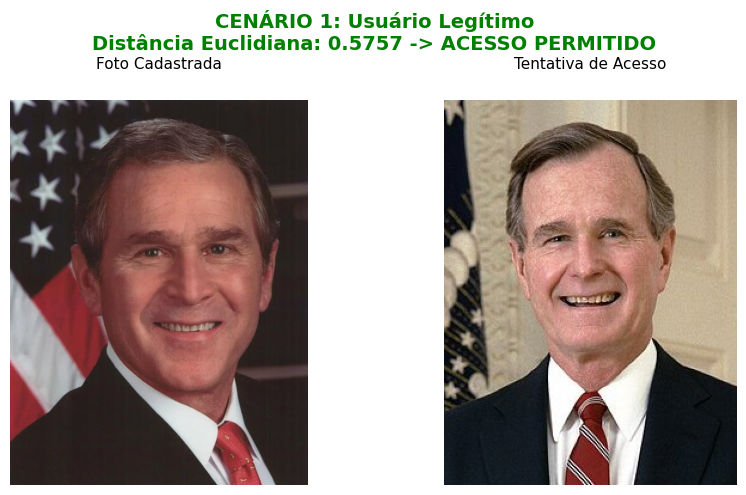

------------------------------------------------------------


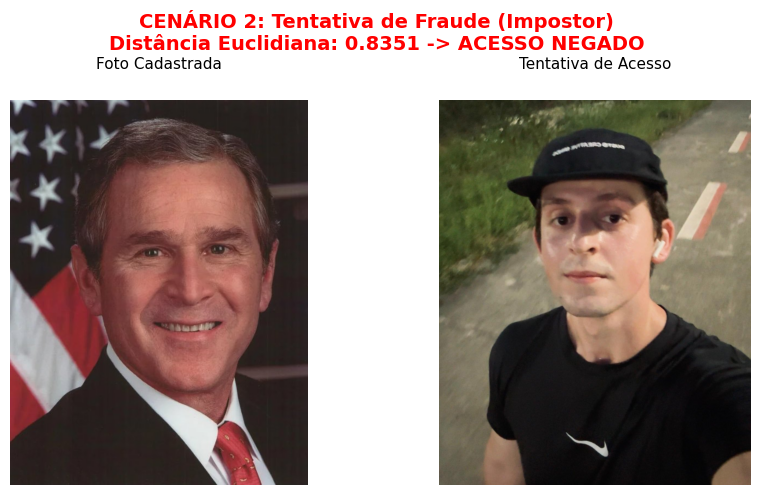

------------------------------------------------------------


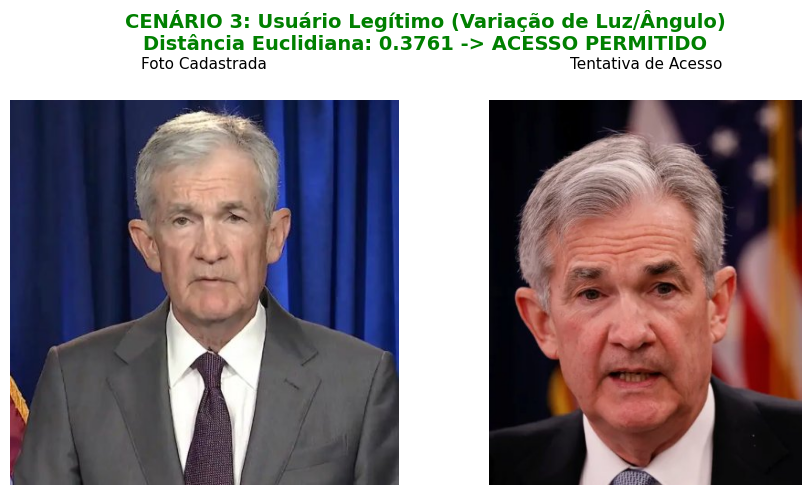

------------------------------------------------------------


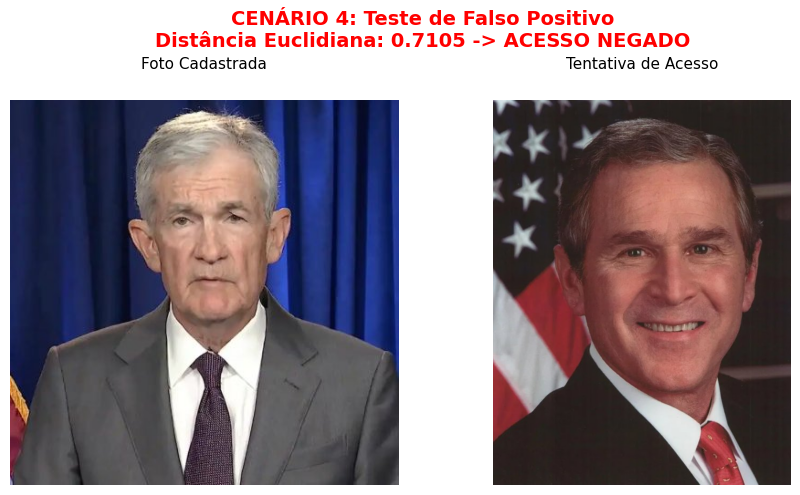

------------------------------------------------------------


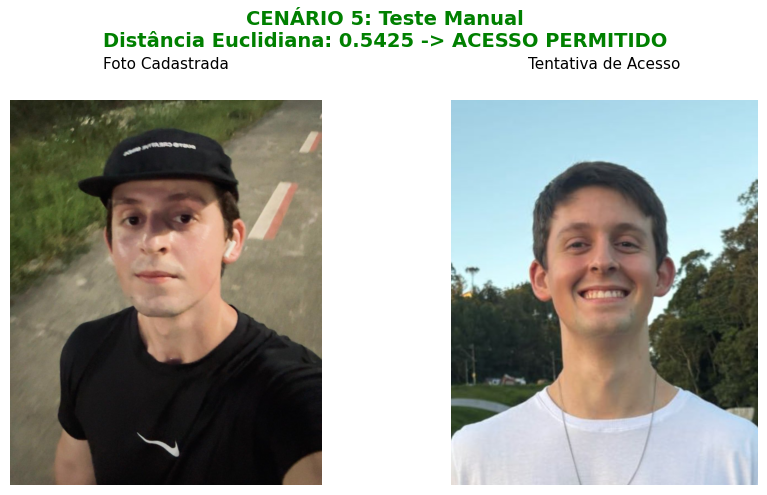

------------------------------------------------------------


In [ ]:
import face_recognition
import numpy as np
import matplotlib.pyplot as plt

# Função para processar as imagens, calcular a distância e gerar o gráfico
def testar_verificacao(caminho_img1, caminho_img2, titulo_teste, threshold=0.6):
    try:
        # Carrega as imagens
        img1 = face_recognition.load_image_file(caminho_img1)
        img2 = face_recognition.load_image_file(caminho_img2)

        # Extrai os embeddings (vetores de 128 dimensões matemáticos)k
        encodings1 = face_recognition.face_encodings(img1)
        encodings2 = face_recognition.face_encodings(img2)

        # Validação de segurança caso a IA não encontre um rosto na foto
        if len(encodings1) == 0 or len(encodings2) == 0:
            print(f"Rosto não detectado em uma das imagens do {titulo_teste}")
            return

        encoding1 = encodings1[0]
        encoding2 = encodings2[0]

        # Calcula a Distância Euclidiana entre os dois vetores
        distancia = np.linalg.norm(encoding1 - encoding2)

        # Verifica se a distância bate o nosso Limiar (Threshold) de segurança
        if distancia <= threshold:
            resultado = "ACESSO PERMITIDO"
            cor = 'green'
        else:
            resultado = "ACESSO NEGADO"
            cor = 'red'

        # --- GERAÇÃO DO GRÁFICO PARA O SLIDE ---
        # Aumentei o figsize para dar mais espaço vertical (de 4 para 5)
        fig, axes = plt.subplots(1, 2, figsize=(9, 5))

        fig.suptitle(f"{titulo_teste}\nDistância Euclidiana: {distancia:.4f} -> {resultado}",
                     fontsize=14, color=cor, fontweight='bold')

        axes[0].imshow(img1)
        axes[0].axis('off')
        # Adicionei \n para dividir os títulos menores em duas linhas e não poluir visualmente
        axes[0].set_title("Foto Cadastrada\n", fontsize=11, pad=10)

        axes[1].imshow(img2)
        axes[1].axis('off')
        axes[1].set_title("Tentativa de Acesso\n", fontsize=11, pad=10)

        # --- O SEGREDO PARA NÃO SOBREPOR TEXTOS ---
        plt.tight_layout()
        # Força um espaço no topo da imagem para caber o título principal de 2 linhas
        plt.subplots_adjust(top=0.80)

        plt.show()
        print("-" * 60)

    except FileNotFoundError:
        print(f"Erro: Imagens para o {titulo_teste} não encontradas. Verifique os nomes dos arquivos.")
    except Exception as e:
        print(f"Erro inesperado no {titulo_teste}: {e}")

# ==========================================
# EXECUÇÃO DOS CENÁRIOS DE TESTE
# ==========================================

# Lista de testes: (Imagem 1, Imagem 2, Título do Teste)
cenarios = [
    # Cenário 1: O caso ideal. Mesma pessoa, fotos parecidas.
    ("/content/sample_data/bush_1.jpg", "/content/sample_data/bush_2.jpg", "CENÁRIO 1: Usuário Legítimo"),

    # Cenário 2: A tentativa de invasão óbvia.
    ("/content/sample_data/bush_1.jpg", "/content/sample_data/daniel.jpg", "CENÁRIO 2: Tentativa de Fraude (Impostor)"),

    # Cenário 3: Mostrando a robustez. Mesma pessoa, mas com iluminação/ângulo diferente.
    ("/content/sample_data/powell_1.jpg", "/content/sample_data/powell_2.jpg", "CENÁRIO 3: Usuário Legítimo (Variação de Luz/Ângulo)"),

    # Cenário 4: O teste extremo. Pessoas diferentes, mas de mesma faixa etária/estilo.
    ("/content/sample_data/powell_1.jpg", "/content/sample_data/bush_1.jpg", "CENÁRIO 4: Teste de Falso Positivo"),

    # Cenário 5: O teste manual.
    ("/content/sample_data/daniel.jpg", "/content/sample_data/daniel_3.jpg", "CENÁRIO 5: Teste Manual")
]

# Roda o loop para gerar as imagens de todos os cenários
for img1, img2, titulo in cenarios:
    testar_verificacao(img1, img2, titulo)